# 宿題：T = 5 で直接法を使って家計ブロックのヤコビアンを求める

講義ノート `sequence_space_jacobian_lecture_notes_ch4_11.pdf`
**第7章「直接法：ヤコビアンを一列ずつ計算する」** の実装。
章末確認問題1「$T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ」に答える。

モデルは Krusell=Smith。既存の `8_2_krusell_and_smith.py` のパラメータ
（`replicate_model = 0`、すなわち Krusell and Smith 1998）を引き継ぐ。

このノートは**宿題に必要なものだけ**を置く。精度の検証、計算量の測定、
フェイクニュース法、ライブラリとの突き合わせ、キャリブレーションの詳細は
`02_experiments.ipynb` にある。

| 節 | 内容 | ノートの対応箇所 |
|---|---|---|
| 1 | 既存コードと SSJ の関係 | 4.1–4.3 |
| 2 | モデルとタイミング規約 | 記号とタイミング |
| 3 | 定常状態 | 4.1 |
| 4 | ブロック写像 $H$ | 4.5–4.8 |
| 5 | **章末確認問題1**：$J^{K,r}_{:,3}$ を一列だけ求める | 7.2 |
| 6 | 全列を並べてヤコビアン完成 | 7.1, 7.3 |
| 7 | 章末確認問題 1–5 の答え | 7.11 |

**実行**: `.venv` のカーネルを使う。
```bash
uv venv --python 3.12 .venv
uv pip install --python .venv/bin/python numpy pandas matplotlib pydantic jaxtyping beartype ipykernel
```

---
## 1. 既存コードと SSJ の関係

既存の `8_2_krusell_and_smith.py` とこのノートは「同じ Krusell=Smith」だが、
**解いている問題が違う**。

| | 既存コード（KS 1998 の元祖解法） | SSJ |
|---|---|---|
| 集計変動 | $A \in \{0.99, 1.01\}$ の確率的ショック | なし。決定論的な定常状態のまわりの**完全予見**摂動 |
| 集計状態の扱い | $K$ を状態変数に持ち、予測式 $\log K' = a_0 + a_1 \log K$ で近似 | 価格経路 $\{r_t, w_t\}_{t=0}^{T-1}$ を所与とする**有限期間の写像** |
| 家計の状態 | $(a, l, K, A)$ の4次元 | $(a, e)$ の2次元 |
| 解法 | VFI + 6000期シミュレーション + OLS で係数更新 | 定常状態を1回解く + 後ろ向き/前向きを $T$ ステップ |
| 出力 | 政策関数と予測係数 | ヤコビアン $J^{K,r},\ J^{K,w},\ J^{C,r},\ J^{C,w}$ |

つまり **$K$ グリッド・予測式・シミュレーション・OLS は全部消える**。
残るのはノート 7.2 の3段階だけ:

1. 終端 $V_T = V_{ss}$ から**後ろ向き**に政策 $\{a_t, c_t\}$
2. 初期 $D_0 = D_{ss}$ から**前向き**に分布 $\{D_t\}$
3. **集計** $K_t = a_t' D_t$

引き継ぐのはパラメータだけ:
$\alpha = 0.36$, $\delta = 0.025$, $\beta = 0.99$, $\bar l = 0.3271$, 失業保険 $= 0.07$, 効用 $= \log c$。

なお $e$（雇用状態）は既存コードの $l$ と同じもので、名前が変わっただけ。
$A$ は集計状態なので個別状態には残らない。

---
## 2. モデルとタイミング規約

ノート ii ページ「通読のための記号とタイミング」に合わせる。

**時点 $t$ の冒頭**に家計は資本 $k_{t-1}$ と個別状態 $e_t$ を持つ。
価格 $(r_t, w_t)$ を所与に消費 $c_t$ と期末資本 $k_t$ を選ぶ:

$$c_t + k_t = (1 + r_t)\,k_{t-1} + y_t(e_t), \qquad k_t \ge 0$$

所得は既存コードの `replicate_model = 0` に合わせて

$$y_t(e) = \begin{cases} 0.07 & e = \text{失業（水準。}w\text{ に比例しない）}\\ w_t \cdot \bar{l} & e = \text{就業}\end{cases}$$

効用は $\log c$。

**分布と遷移**

- $D_t$ : 時点 $t$ 冒頭の $(e_t, k_{t-1})$ 上の分布
- $\Lambda_t$ : 政策と個別状態遷移から作られる遷移行列。$D_{t+1} = \Lambda_t^{\top} D_t$
- 集計: $K_t = k_t' D_t$, $C_t = c_t' D_t$

**企業**は時点 $t$ に期首資本 $K_{t-1}$ と労働 $N$ で生産する:

$$r_t = \alpha Z \left(\frac{K_{t-1}}{N}\right)^{\alpha-1} - \delta, \qquad
  w_t = (1-\alpha) Z \left(\frac{K_{t-1}}{N}\right)^{\alpha}$$

**求めるもの**（ノート式 2・3）

$$\begin{pmatrix} \mathcal{K} \\ \mathcal{C} \end{pmatrix} = H\!\left(\begin{pmatrix} r \\ w \end{pmatrix}\right)
\ \Longrightarrow\
\begin{pmatrix} d\mathcal{K} \\ d\mathcal{C} \end{pmatrix}
= \begin{pmatrix} J^{K,r} & J^{K,w} \\ J^{C,r} & J^{C,w} \end{pmatrix}
  \begin{pmatrix} dr \\ dw \end{pmatrix}$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ks
from ks import DifferenceScheme, Employment

plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(precision=6, suppress=True, linewidth=140)

T = 5          # 宿題の指定
EPS = 1e-4     # 差分幅

### 型について

配列がどんな形なのかは型注釈から読める。たとえば貯蓄政策を1期分求める関数は

```python
def backward_egm(
    expected_Va: MarginalValue,   # Float[np.ndarray, "n_e n_a"]
    a_grid:      AssetGrid,       # Float[np.ndarray, "n_a"]
    y:           IncomeByState,   # Float[np.ndarray, "n_e"]
    r: float, beta: float, eis: float,
) -> BackwardStep:                # NamedTuple(Va, a, c) いずれも "n_e n_a"
```

軸の名前は `n_e` = 雇用状態の数（2）、`n_a` = 資産グリッドの点数、`T` = 切断期間。
形を取り違えると実行時に落ちる（`KS_TYPECHECK=0` で無効化できる）。

In [2]:
model = ks.KSModel.build()      # パラメータ（pydantic で検証済み）と導出された配列

print("パラメータ")
for name in ['alpha', 'delta', 'beta', 'eis', 'lbar', 'unemployment_insurance', 'n_a', 'a_max']:
    print(f"   {name:24s} = {getattr(model.calibration, name)}")

print("\n導出された量")
print(f"   雇用の遷移行列 Pi        shape = {model.Pi.shape}")
display(pd.DataFrame(model.Pi, index=['失業', '就業'], columns=["失業'", "就業'"]))
print(f"   定常失業率 u              = {model.u_ss:.6f}")
print(f"   集計労働 N = lbar (1 - u) = {model.N:.6f}")
print(f"   定常 TFP  Z               = {model.Z:.6f}")
print(f"   資産グリッド a_grid       shape = {model.a_grid.shape}  "
      f"[{model.a_grid[0]:.2f}, {model.a_grid[-1]:.2f}]")
print()
print("Pi は既存コードの (A, l) 4状態チェーンから A を積分して作った。詳細は 02_experiments.ipynb 節1。")

パラメータ
   alpha                    = 0.36
   delta                    = 0.025
   beta                     = 0.99
   eis                      = 1.0
   lbar                     = 0.3271
   unemployment_insurance   = 0.07
   n_a                      = 200
   a_max                    = 300.0

導出された量
   雇用の遷移行列 Pi        shape = (2, 2)


,失業',就業'
失業,0.507440,0.492560
就業,0.037074,0.962926


   定常失業率 u              = 0.070000
   集計労働 N = lbar (1 - u) = 0.304203
   定常 TFP  Z               = 1.000000
   資産グリッド a_grid       shape = (200,)  [0.00, 300.00]

Pi は既存コードの (A, l) 4状態チェーンから A を積分して作った。詳細は 02_experiments.ipynb 節1。


---
## 3. 定常状態

資本市場を清算する $K$ を求める（家計の資産需要 $= K$）。

**このキャリブレーションの注意点**: $\beta = 0.99$ なので非忍耐性の境界は
$1/\beta - 1 = 0.010101$。均衡 $r$ はこれに極端に近く $\beta(1+r) = 0.99990$ になる。
そのため分布の前向き反復が極端に遅い。ここでは定常分布を反復ではなく
線形方程式 $D = \Lambda_{ss}^{\top} D,\ \mathbf{1}'D = 1$ で直接解いている
（状態数は $2 \times 200 = 400$ しかないので密行列で十分）。

これは 7.7 節「基準走行を差し引く理由」と直結する。定常状態が甘いと基準走行 $Y^0$ が
平坦にならず、差分に誤差が乗る（→ 02 節3で実験）。

In [3]:
ss = ks.solve_general_equilibrium(model)
Y = model.output(ss.K)

print(f"K   = {ss.K:.8f}       (KS(1998) の報告値は約 11.5)")
print(f"r   = {ss.prices.r:.8f}       1/beta - 1 = {model.calibration.r_impatience_bound:.8f}")
print(f"      beta * (1 + r)   = {model.calibration.beta * (1 + ss.prices.r):.8f}   <- 1 に極端に近い")
print(f"w   = {ss.prices.w:.8f}")
print(f"Y   = {Y:.8f}        K/Y = {ss.K / (4 * Y):.4f} (年率)")
print(f"C   = {ss.C:.8f}")
print(f"所得 y = [失業 {ss.y[Employment.UNEMPLOYED]:.4f}, 就業 {ss.y[Employment.EMPLOYED]:.4f}]"
      f"   代替率 = {ss.y[0] / ss.y[1]:.3f}")
print()
print(f"定常分布の残差 max|Λ'D - D| = {ss.distribution_residual:.3e}")
print(f"資産グリッド上端10点の質量   = {ss.top_grid_mass:.3e}")

K   = 11.60936401       (KS(1998) の報告値は約 11.5)
r   = 0.00999853       1/beta - 1 = 0.01010101
      beta * (1 + r)   = 0.99989854   <- 1 に極端に近い
w   = 2.37449987
Y   = 1.12864060        K/Y = 2.5715 (年率)
C   = 0.84330650
所得 y = [失業 0.0700, 就業 0.7767]   代替率 = 0.090

定常分布の残差 max|Λ'D - D| = 4.720e-16
資産グリッド上端10点の質量   = -7.362e-14


---
## 4. ブロック写像 $H$

`ks.simulate_transition(model, ss, r_path, w_path)` が写像 $H$ そのもの。
中身はノート 7.2 の3段階:

```python
# 第1段階: 後ろ向き（終端 V_T = V_ss）
Va = ss.Va
for t in reversed(range(T)):
    step = backward_egm(model.Pi @ Va, model.a_grid, model.income(w_path[t]), r_path[t], beta, eis)
    Va, a_path[t], c_path[t] = step.Va, step.a, step.c

# 第2・3段階: 前向きに分布を進めつつ集計（初期 D_0 = D_ss）
D = ss.D
for t in range(T):
    K[t] = D . a_path[t]
    C[t] = D . c_path[t]
    D = forward_step(D, model.Pi, asset_lottery(model.a_grid, a_path[t]))   # D_{t+1} = Λ_t' D_t
```

**まず基準走行 $Y^0$ を確認する**（ノート 7.7）。価格を定常値に固定して流したとき、
$K^0_t$ が $K_{ss}$ でぴたりと平坦なら、定常状態が数値的に正しく解けている。

In [4]:
r_ss = np.full(T, ss.prices.r)
w_ss = np.full(T, ss.prices.w)

baseline = ks.simulate_transition(model, ss, r_ss, w_ss)

print("基準走行 K^0_t =", np.array2string(baseline.K, precision=10))
print("K^0_t - K_ss   =", "  ".join(f"{v:+.3e}" for v in baseline.K - ss.K))
print("C^0_t - C_ss   =", "  ".join(f"{v:+.3e}" for v in baseline.C - ss.C))
print()
print("-> 1e-12 のオーダーで平坦。もしここが 1e-9 だと、eps = 1e-4 で割った瞬間に")
print("   1e-5 の誤差がヤコビアンに乗る。")

基準走行 K^0_t = [11.6093640145 11.6093640145 11.6093640145 11.6093640145 11.6093640145]
K^0_t - K_ss   = -6.253e-13  -1.114e-12  -1.478e-12  -1.716e-12  -1.826e-12
C^0_t - C_ss   = +6.254e-13  +4.955e-13  +3.658e-13  +2.359e-13  +1.062e-13

-> 1e-12 のオーダーで平坦。もしここが 1e-9 だと、eps = 1e-4 で割った瞬間に
   1e-5 の誤差がヤコビアンに乗る。


---
## 5. 章末確認問題1： $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める

> **問**: $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ。

### 手順（ノート 7.2）

**準備**: 基準走行 $K^0$ を、同じ有限期間・同じ終端条件・同じ数値手順で流しておく。

**(1) 摂動経路を作る**（式 7.4）

$$r^{3,+}_t = r_{ss} + \varepsilon \cdot \mathbb{1}\{t = 3\}
\ \Longrightarrow\
r^{3,+} = (r_{ss},\ r_{ss},\ r_{ss},\ r_{ss} + \varepsilon,\ r_{ss})$$

賃金経路は定常値に固定。

**(2) 後ろ向きに政策を求める**（式 7.5）。終端 $V_5 = V_{ss}$ から

$$V^{3,+}_t = v\left(V^{3,+}_{t+1},\ r^{3,+}_t,\ w_{ss}\right), \qquad t = 4, 3, 2, 1, 0$$

同時に $a^{3,+}_t$, $c^{3,+}_t$, $\Lambda^{3,+}_t$ を保存。

**(3) 前向きに分布を求める**（式 7.6）。初期 $D_0 = D_{ss}$ から

$$D^{3,+}_{t+1} = \left(\Lambda^{3,+}_t\right)^{\top} D^{3,+}_t, \qquad t = 0, \dots, 4$$

**(4) 集計して差分をとる**（式 7.7, 7.9）

$$K^{3,+}_t = \left(a^{3,+}_t\right)^{\top} D^{3,+}_t,
\qquad
J^{K,r}_{t,3} \approx \frac{K^{3,+}_t - K^0_t}{\varepsilon}$$

下で実際に回して、各段階の中身を見る。

In [5]:
# (1) 摂動経路
r_pert = r_ss.copy()
r_pert[3] += EPS
print("(1) r 経路 =", np.array2string(r_pert, precision=8))

# (2)(3) 内部を保存しながら流す
pert = ks.simulate_transition(model, ss, r_pert, w_ss, store_internals=True)

print("\n(2) 各時点の政策が定常政策からどれだけずれたか  max|a_t - a_ss|:")
for t in range(T):
    tag = ("  <- ショックの時点" if t == 3 else
           "  <- 将来なので定常のまま" if t > 3 else "")
    print(f"    t = {t}:  {np.max(np.abs(pert.a[t] - ss.a)):.6e}{tag}")

print("\n(3) 各時点の分布が定常分布からどれだけずれたか  max|D_t - D_ss|:")
for t in range(T):
    tag = "  <- 初期条件なのでゼロ" if t == 0 else ""
    print(f"    t = {t}:  {np.max(np.abs(pert.D[t] - ss.D)):.6e}{tag}")

# (4) 集計して差分
column_3 = (pert.K - baseline.K) / EPS
print("\n(4) 集計と差分")
print("    基準走行  K^0_t     =", np.array2string(baseline.K, precision=10))
print("    摂動走行  K^{3,+}_t =", np.array2string(pert.K, precision=10))
print("    第3列 J^{K,r}[:, 3] =", np.array2string(column_3, precision=6))

(1) r 経路 = [0.00999853 0.00999853 0.00999853 0.01009853 0.00999853]

(2) 各時点の政策が定常政策からどれだけずれたか  max|a_t - a_ss|:
    t = 0:  7.055431e-05
    t = 1:  7.127045e-05
    t = 2:  7.200596e-05
    t = 3:  2.969998e-02  <- ショックの時点
    t = 4:  1.785239e-13  <- 将来なので定常のまま

(3) 各時点の分布が定常分布からどれだけずれたか  max|D_t - D_ss|:
    t = 0:  0.000000e+00  <- 初期条件なのでゼロ
    t = 1:  6.080200e-07
    t = 2:  7.132393e-07
    t = 3:  8.220254e-07
    t = 4:  5.246900e-06

(4) 集計と差分
    基準走行  K^0_t     = [11.6093640145 11.6093640145 11.6093640145 11.6093640145 11.6093640145]
    摂動走行  K^{3,+}_t = [11.6094317798 11.6095002352 11.6095693923 11.6107167338 11.6107146161]
    第3列 J^{K,r}[:, 3] = [ 0.677653  1.362207  2.053778 13.527192 13.506016]


### 確認問題2の答えもここに出ている

> **問**: なぜ時点3の金利だけを動かしても、政策を $t = 3$ だけ解けばよいわけではないのか。

上の (2) を見ると、$t = 0, 1, 2$ でも政策が定常からずれている。
$t < 3$ の政策を求めるには**将来の** $r_3$ が必要だから。オイラー方程式
$u'(c_t) = \beta E_t[(1+r_{t+1}) u'(c_{t+1})]$ を通じて、時点3の金利上昇は
時点2の消費・貯蓄を変え、それがさらに時点1・0に伝わる。
だから**終端から時点0までの後ろ向き計算がまるごと必要**になる。

逆に $t = 4$ の政策は $r_4 = r_{ss}$ しか見ないので定常政策のまま（$10^{-13}$）。
それでも $K_4$ は大きく動く。理由は**分布** $D_4$ が動いているから
（政策効果と分布効果、ノート 4.7・6.5）。

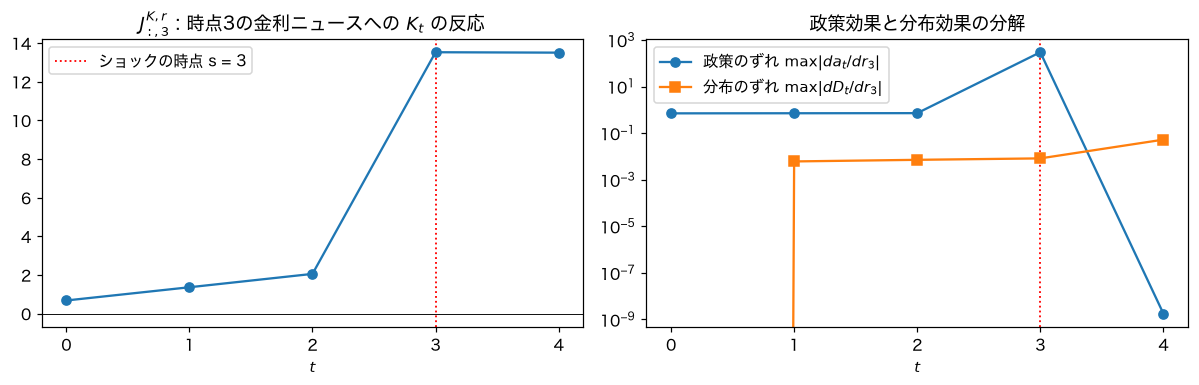

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].axhline(0, color='k', lw=0.6)
ax[0].axvline(3, color='r', ls=':', lw=1.2, label='ショックの時点 s = 3')
ax[0].plot(range(T), column_3, 'o-')
ax[0].set_title('$J^{K,r}_{:,3}$ : 時点3の金利ニュースへの $K_t$ の反応')
ax[0].set_xlabel('$t$'); ax[0].set_xticks(range(T)); ax[0].legend()

ax[1].axhline(0, color='k', lw=0.6)
ax[1].axvline(3, color='r', ls=':', lw=1.2)
ax[1].plot(range(T), [np.max(np.abs(pert.a[t] - ss.a)) / EPS for t in range(T)],
           'o-', label=r'政策のずれ $\max|da_t/dr_3|$')
ax[1].plot(range(T), [np.max(np.abs(pert.D[t] - ss.D)) / EPS for t in range(T)],
           's-', label=r'分布のずれ $\max|dD_t/dr_3|$')
ax[1].set_yscale('log'); ax[1].set_xlabel('$t$'); ax[1].set_xticks(range(T))
ax[1].set_title('政策効果と分布効果の分解'); ax[1].legend()

plt.tight_layout(); plt.show()

右の図が「政策効果と分布効果」（ノート 4.7）を分けている。

- **政策のずれ**は $t \le 3$ で大きく、$t = 4$ でゼロに落ちる（将来の価格は定常なので）
- **分布のずれ**は $t = 0$ でゼロ（初期条件 $D_0 = D_{ss}$）、その後じわじわ増えて $t = 4$ で最大

$K_t$ の反応はこの2つの和である。

---
## 6. 全部の列を並べる → ヤコビアン完成

節5をすべての $s = 0, \dots, 4$ と、入力 $r$・$w$ の両方について繰り返す
（ノート 7.3 の図7.1）。

```
 s = 0 の摂動      s = 1 の摂動      ...      s = T-1 の摂動
     ↓                 ↓                          ↓
 後ろ向き T ステップ  後ろ向き T ステップ   ...  後ろ向き T ステップ
     ↓                 ↓                          ↓
 前向き T ステップ    前向き T ステップ     ...  前向き T ステップ
     ↓                 ↓                          ↓
    第0列              第1列                     第T-1列
```

In [7]:
J = ks.jacobian_direct(model, ss, T=T, eps=EPS, scheme=DifferenceScheme.ONE_SIDED)

for output, input_, label in [('K', 'r', r'$J^{K,r}$'), ('K', 'w', r'$J^{K,w}$'),
                              ('C', 'r', r'$J^{C,r}$'), ('C', 'w', r'$J^{C,w}$')]:
    print(f"{label}   (t, s) 要素 = d{output}_t / d{input_}_s"
          f"     行 t = 応答の時点, 列 s = ショックの時点")
    display(pd.DataFrame(J.get(output, input_),
                         index=[f't={t}' for t in range(T)],
                         columns=[f's={s}' for s in range(T)]))

$J^{K,r}$   (t, s) 要素 = dK_t / dr_s     行 t = 応答の時点, 列 s = ショックの時点


,s=0,s=1,s=2,s=3,s=4
t=0,11.478651,0.695170,0.686338,0.677653,0.669101
t=1,11.462863,12.172017,1.379680,1.362207,1.345011
t=2,11.447082,12.154375,12.854783,2.053778,2.027833
t=3,11.431319,12.136760,12.835346,13.527192,2.717688
t=4,11.415581,12.119181,12.815954,13.506016,14.189466


$J^{K,w}$   (t, s) 要素 = dK_t / dw_s     行 t = 応答の時点, 列 s = ショックの時点


,s=0,s=1,s=2,s=3,s=4
t=0,0.300412,-0.003714,-0.003650,-0.003593,-0.003540
t=1,0.299634,0.296715,-0.007348,-0.007227,-0.007117
t=2,0.298857,0.295954,0.293098,-0.010908,-0.010736
t=3,0.298083,0.295193,0.292353,0.289553,-0.014402
t=4,0.297313,0.294435,0.291608,0.288823,0.286074


$J^{C,r}$   (t, s) 要素 = dC_t / dr_s     行 t = 応答の時点, 列 s = ショックの時点


,s=0,s=1,s=2,s=3,s=4
t=0,0.130713,-0.695170,-0.686338,-0.677653,-0.669101
t=1,0.130558,0.139537,-0.686479,-0.677778,-0.669220
t=2,0.130392,0.139344,0.148193,-0.677951,-0.669375
t=3,0.130217,0.139141,0.147966,0.156689,-0.669579
t=4,0.130034,0.138928,0.147727,0.156428,0.165031


$J^{C,w}$   (t, s) 要素 = dC_t / dw_s     行 t = 応答の時点, 列 s = ショックの時点


,s=0,s=1,s=2,s=3,s=4
t=0,0.003791,0.003714,0.003650,0.003593,0.003540
t=1,0.003782,0.003736,0.003661,0.003598,0.003542
t=2,0.003773,0.003728,0.003683,0.003609,0.003547
t=3,0.003762,0.003720,0.003676,0.003632,0.003559
t=4,0.003751,0.003710,0.003668,0.003626,0.003583


In [8]:
# 第5節で1列だけ求めたものと一致することの確認
print("節5で求めた第3列      =", np.array2string(column_3, precision=6))
print("J.K_r[:, 3]           =", np.array2string(J.K_r[:, 3], precision=6))
print("差                    =", np.max(np.abs(column_3 - J.K_r[:, 3])))

節5で求めた第3列      = [ 0.677653  1.362207  2.053778 13.527192 13.506016]
J.K_r[:, 3]           = [ 0.677653  1.362207  2.053778 13.527192 13.506016]
差                    = 0.0


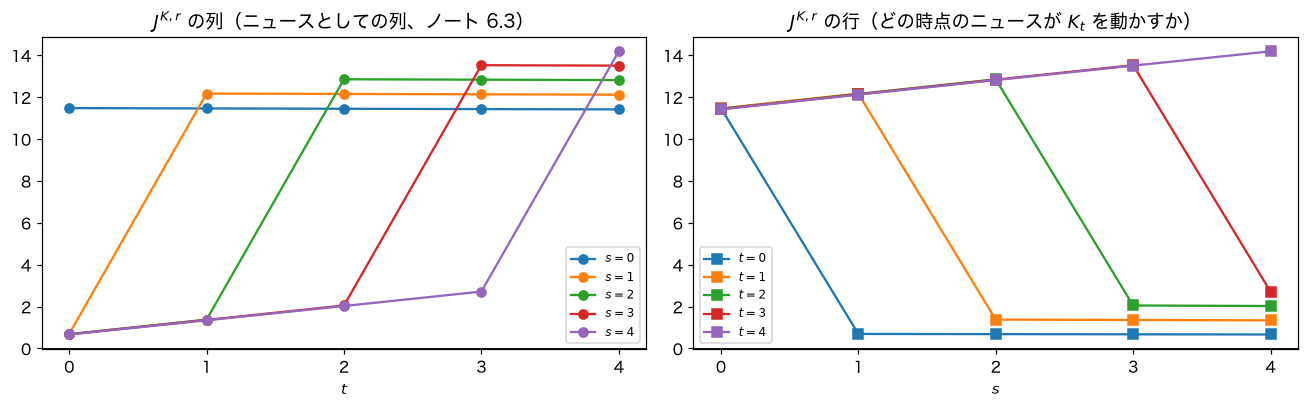

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

for s in range(T):
    ax[0].plot(range(T), J.K_r[:, s], 'o-', label=f'$s={s}$')
ax[0].axhline(0, color='k', lw=0.6)
ax[0].set_title(r'$J^{K,r}$ の列（ニュースとしての列、ノート 6.3）')
ax[0].set_xlabel('$t$'); ax[0].set_xticks(range(T)); ax[0].legend(fontsize=8)

for t in range(T):
    ax[1].plot(range(T), J.K_r[t, :], 's-', label=f'$t={t}$')
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_title(r'$J^{K,r}$ の行（どの時点のニュースが $K_t$ を動かすか）')
ax[1].set_xlabel('$s$'); ax[1].set_xticks(range(T)); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**上側と下側に何が入るか**（ノート 6.4）

- **下三角**（$t \ge s$）: ショックが実現した後の反応。政策効果 + 分布効果の両方。大きい。
- **上三角**（$t < s$）: 将来のニュースへの先回り。政策効果だけ（分布はまだ動いていない）。小さい。

$J^{K,r}$ の第0列がどの行でも $\approx 11.4$ とほぼ一定なのは、$t=0$ の金利上昇が
$K_{ss} \approx 11.6$ の資本所得ショックを与え、それがほぼ恒久的に資産に残るから。
$\beta(1+r) \approx 1$ の設定では家計はほぼ恒常所得仮説的にふるまうので、
受け取った資本所得はほとんど取り崩されない。

### 健全性チェック

各家計の予算制約 $c_t + k_t = (1+r_t)k_{t-1} + y_t(e_t)$ を集計して微分すると

$$\frac{\partial C_0}{\partial r_0} + \frac{\partial K_0}{\partial r_0} = K_{ss},
\qquad
\frac{\partial C_0}{\partial w_0} + \frac{\partial K_0}{\partial w_0} = N,
\qquad
\text{どちらも } s > 0 \text{ ではゼロ}$$

In [10]:
row_r = J.K_r[0] + J.C_r[0]
row_w = J.K_w[0] + J.C_w[0]
print("dC_0/dr_s + dK_0/dr_s =", "  ".join(f"{v:.8f}" for v in row_r))
print(f"     期待値: s=0 で K_ss = {ss.K:.8f}, s>0 で 0")
print(f"     誤差:   s=0 {abs(row_r[0] - ss.K):.3e},   s>0 最大 {np.max(np.abs(row_r[1:])):.3e}")
print()
print("dC_0/dw_s + dK_0/dw_s =", "  ".join(f"{v:.8f}" for v in row_w))
print(f"     期待値: s=0 で N = {model.N:.8f}, s>0 で 0")
print(f"     誤差:   s=0 {abs(row_w[0] - model.N):.3e},   s>0 最大 {np.max(np.abs(row_w[1:])):.3e}")

dC_0/dr_s + dK_0/dr_s = 11.60936401  0.00000000  0.00000000  0.00000000  0.00000000
     期待値: s=0 で K_ss = 11.60936401, s>0 で 0
     誤差:   s=0 2.114e-11,   s>0 最大 2.665e-11

dC_0/dw_s + dK_0/dw_s = 0.30420300  0.00000000  0.00000000  -0.00000000  0.00000000
     期待値: s=0 で N = 0.30420300, s>0 で 0
     誤差:   s=0 7.766e-12,   s>0 最大 2.220e-11


---
## 7. 章末確認問題 7.11 の答え

**1. $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ。**

節5の通り。まとめると:

0. 基準走行 $K^0$ を、同じ $T$・同じ終端条件・同じ数値手順で流しておく（$\varepsilon = 0$）。
1. $r^{3,+} = (r_{ss}, r_{ss}, r_{ss}, r_{ss}+\varepsilon, r_{ss})$、$w$ は定常値に固定。
2. 終端 $V_5 = V_{ss}$ から $t = 4, 3, 2, 1, 0$ の順に後ろ向きに $V^{3,+}_t$ を解き、
   各時点の $a^{3,+}_t,\ c^{3,+}_t,\ \Lambda^{3,+}_t$ を保存。
3. 初期 $D_0 = D_{ss}$ から $t = 0, \dots, 4$ の順に $D^{3,+}_{t+1} = (\Lambda^{3,+}_t)^{\top} D^{3,+}_t$。
4. 各時点で $K^{3,+}_t = (a^{3,+}_t)^{\top} D^{3,+}_t$ を集計し、
   $J^{K,r}_{t,3} = (K^{3,+}_t - K^0_t)/\varepsilon$。

**2. なぜ時点3の金利だけを動かしても、政策を $t = 3$ だけ解けばよいわけではないのか。**

$t < 3$ の政策を求めるには将来の $r_3$ が必要だから。オイラー方程式
$u'(c_t) = \beta E_t[(1+r_{t+1})u'(c_{t+1})]$ を通じて、時点3の金利は時点2の意思決定に効き、
それが時点1・0へ順に伝わる。だから終端から時点0までの後ろ向き計算がまるごと必要。
節5の出力で $t = 0, 1, 2$ の政策が定常からずれていることを確認した。

なお $t = 4$ の政策は定常のままだが $K_4$ は動く。**分布** $D_4$ がすでにずれているから。

**3. 直接法の高価な家計ステップ数が $O(T^2)$ になることを、列数と各列の計算長から示せ。**

列は $s = 0, \dots, T-1$ の $T$ 本。各列につき

- 後ろ向き家計ステップ: 終端 $T$ から $0$ まで $\approx T$ 回
- 前向き分布ステップ: $0$ から $T-1$ まで $\approx T$ 回

したがって $T \times T = O(T^2)$。入力が $n_x$ 個なら $O(n_x T^2)$。
出力を増やしても後ろ向き計算の回数は増えない（同じ政策・分布から追加の集計量を作れる）が、
保存と集計のコストは増える。→ `02_experiments.ipynb` 節4 で実測。

**4. 中央差分の利点と欠点を述べよ。**

利点: 切断誤差が $O(\varepsilon)$ から $O(\varepsilon^2)$ に落ちる。
$\varepsilon = 10^{-4}$ で片側 $2.6\times10^{-4}$ に対し中央 $2.9\times10^{-8}$。

欠点: 摂動走行が正負2本ずつ必要で計算量が約2倍。
また $\varepsilon$ を小さくしすぎると丸め誤差が支配的になるのは片側と同じで、
$\varepsilon \le 10^{-7}$ では逆に悪化する。→ `02_experiments.ipynb` 節3 で実測。

**5. 基準走行 $Y^0$ を差し引くことが、特に小さい $\varepsilon$ で重要になる理由。**

有限期間・終端条件・補間・グリッド・収束許容誤差のせいで $Y^0 \ne Y_{ss}\mathbf{1}$ になる。
$Y_{ss}\mathbf{1}$ を差し引くと、この摂動と無関係な基準誤差まで $1/\varepsilon$ 倍される。
$\varepsilon$ が小さいほど倍率が大きいので、$\varepsilon$ を小さくして切断誤差を減らそうとすると
基準誤差の方が爆発する。同じ数値手順で走らせた $Y^0$ を差し引けば共通誤差が相殺される。
→ `02_experiments.ipynb` 節3 で、わざと甘い定常状態を使って実測。

---

## まとめ

- 直接法は Sequence Space Jacobian の**定義そのまま**の計算。
  一列ごとに「後ろ向き $T$ ステップ + 前向き $T$ ステップ」を回す。
- 正しいが遅い。列の間の**時間並進**と**分布効果の定常伝播**という2つの重複を
  使っていないから。これを取り除くのが第8章のフェイクニュース・アルゴリズム。
- 直接法の価値は速さではなく、**高速法・解析微分・自動微分を検証する基準**に
  なること（ノート 7.8）。

続きは `02_experiments.ipynb`。